## IMPORT LIBRARIES

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Libraries are imported for data analysis, visualization, and machine learning

## LOAD DATASET

In [36]:
df = pd.read_csv("/content/Battery_Dataset.csv")
df.head()

,type,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,-1,4,47,0,1,00001.csv,0.983689,0.054543,0.183130
1,0,24,47,1,2,00002.csv,0.983689,0.054543,0.183130
2,1,4,47,2,3,00003.csv,0.983689,0.054543,0.183130
3,0,24,47,3,4,00004.csv,0.983689,0.051825,0.152493
4,-1,4,47,4,5,00005.csv,0.925990,0.051825,0.152493


## DATA UNDERSTANDING

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7368 entries, 0 to 7367
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   type                 7368 non-null   int64  
 1   ambient_temperature  7368 non-null   int64  
 2   battery_id           7368 non-null   int64  
 3   test_id              7368 non-null   int64  
 4   uid                  7368 non-null   int64  
 5   filename             7368 non-null   object 
 6   Capacity             7368 non-null   float64
 7   Re                   7368 non-null   float64
 8   Rct                  7368 non-null   float64
dtypes: float64(3), int64(5), object(1)
memory usage: 518.2+ KB


In [38]:
df.columns

Index(['type', 'ambient_temperature', 'battery_id', 'test_id', 'uid',
       'filename', 'Capacity', 'Re', 'Rct'],
      dtype='object')

In [39]:
df.shape

(7368, 9)

The dataset contains battery parameters such as temperature, resistance, and capacity used to analyze battery health.

## DATA CLEANING

In [40]:
df = df.dropna()

Missing values are removed to improve model performance.

## DESCRIPTIVE STATISTICS

In [41]:
df.describe()

,type,ambient_temperature,battery_id,test_id,uid,Capacity,Re,Rct
count,7368.000000,7368.000000,7368.000000,7368.000000,7368.000000,7368.000000,7368.000000,7368.000000
mean,0.002443,19.911238,32.213762,166.309718,3735.133415,0.824926,0.077739,0.125128
std,0.865297,11.210718,16.643714,139.771878,2190.232696,0.250283,0.022584,0.044834
min,-1.000000,4.000000,5.000000,0.000000,1.000000,0.000000,0.026691,0.038781
25%,-1.000000,4.000000,18.000000,54.000000,1842.750000,0.775098,0.060875,0.084685
50%,0.000000,24.000000,36.000000,125.000000,3686.500000,0.894803,0.074693,0.118383
75%,1.000000,24.000000,45.000000,244.250000,5603.250000,0.986519,0.095817,0.158926
max,1.000000,44.000000,56.000000,555.000000,7565.000000,1.292025,0.142128,0.238124


In [42]:
# Mean (average)

print("Mean values:\n")
print(df.mean(numeric_only=True))

Mean values:

type                      0.002443
ambient_temperature      19.911238
battery_id               32.213762
test_id                 166.309718
uid                    3735.133415
Capacity                  0.824926
Re                        0.077739
Rct                       0.125128
dtype: float64


In [43]:
# Median

print("\nMedian values:\n")
print(df.median(numeric_only=True))


Median values:

type                      0.000000
ambient_temperature      24.000000
battery_id               36.000000
test_id                 125.000000
uid                    3686.500000
Capacity                  0.894803
Re                        0.074693
Rct                       0.118383
dtype: float64


In [44]:
# Mode

print("\nMode values:\n")
print(df.mode(numeric_only=True).iloc[0])


Mode values:

type                    1.000000
ambient_temperature    24.000000
battery_id              5.000000
test_id                 0.000000
uid                     1.000000
Capacity                0.000000
Re                      0.069997
Rct                     0.159872
Name: 0, dtype: float64


In [45]:
# Minimum values

print("\nMinimum values:\n")
print(df.min(numeric_only=True))


Minimum values:

type                  -1.000000
ambient_temperature    4.000000
battery_id             5.000000
test_id                0.000000
uid                    1.000000
Capacity               0.000000
Re                     0.026691
Rct                    0.038781
dtype: float64


In [46]:
# Minimum values

print("\nMinimum values:\n")
print(df.min(numeric_only=True))


Minimum values:

type                  -1.000000
ambient_temperature    4.000000
battery_id             5.000000
test_id                0.000000
uid                    1.000000
Capacity               0.000000
Re                     0.026691
Rct                    0.038781
dtype: float64


In [47]:
# Standard Deviation

print("\nStandard Deviation:\n")
print(df.std(numeric_only=True))


Standard Deviation:

type                      0.865297
ambient_temperature      11.210718
battery_id               16.643714
test_id                 139.771878
uid                    2190.232696
Capacity                  0.250283
Re                        0.022584
Rct                       0.044834
dtype: float64


In [48]:
# Skewness

print("\nSkewness:\n")
print(df.skew(numeric_only=True))



Skewness:

type                  -0.004700
ambient_temperature   -0.026970
battery_id            -0.470474
test_id                0.941181
uid                    0.045660
Capacity              -1.996526
Re                     0.323583
Rct                    0.293914
dtype: float64


In [49]:
# Kurtosis

print("\nKurtosis:\n")
print(df.kurtosis(numeric_only=True))


Kurtosis:

type                  -1.664538
ambient_temperature   -0.298408
battery_id            -1.038945
test_id               -0.071370
uid                   -1.192436
Capacity               3.539969
Re                    -0.340480
Rct                   -0.930748
dtype: float64


## DATA VISUALISATION

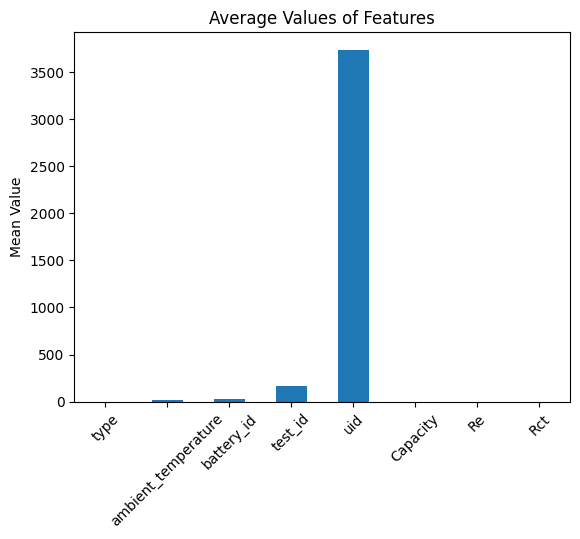

In [50]:
## Bar Chart

df_numeric = df.select_dtypes(include=[np.number])

df_numeric.mean().plot(kind='bar')
plt.title("Average Values of Features")
plt.ylabel("Mean Value")
plt.xticks(rotation=45)
plt.show()

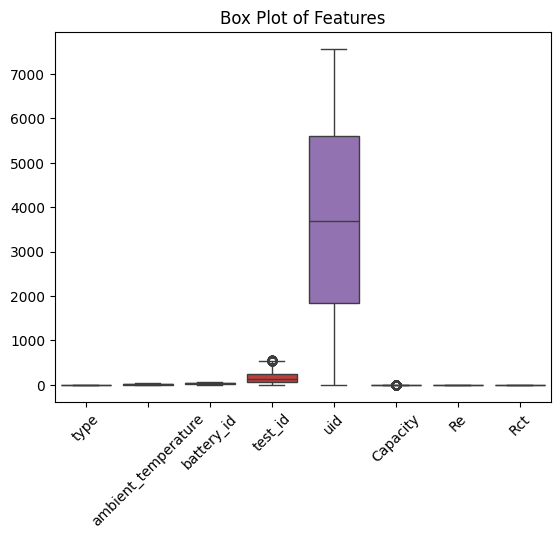

In [51]:
## Box Plot

sns.boxplot(data=df_numeric)
plt.title("Box Plot of Features")
plt.xticks(rotation=45)
plt.show()

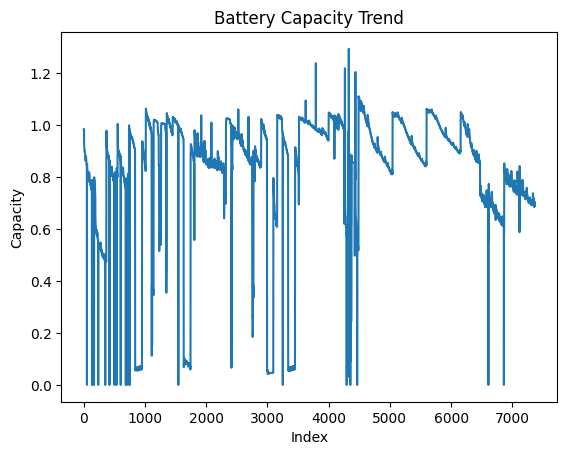

In [52]:
## Line Graph

df["Capacity"].plot()
plt.title("Battery Capacity Trend")
plt.xlabel("Index")
plt.ylabel("Capacity")
plt.show()

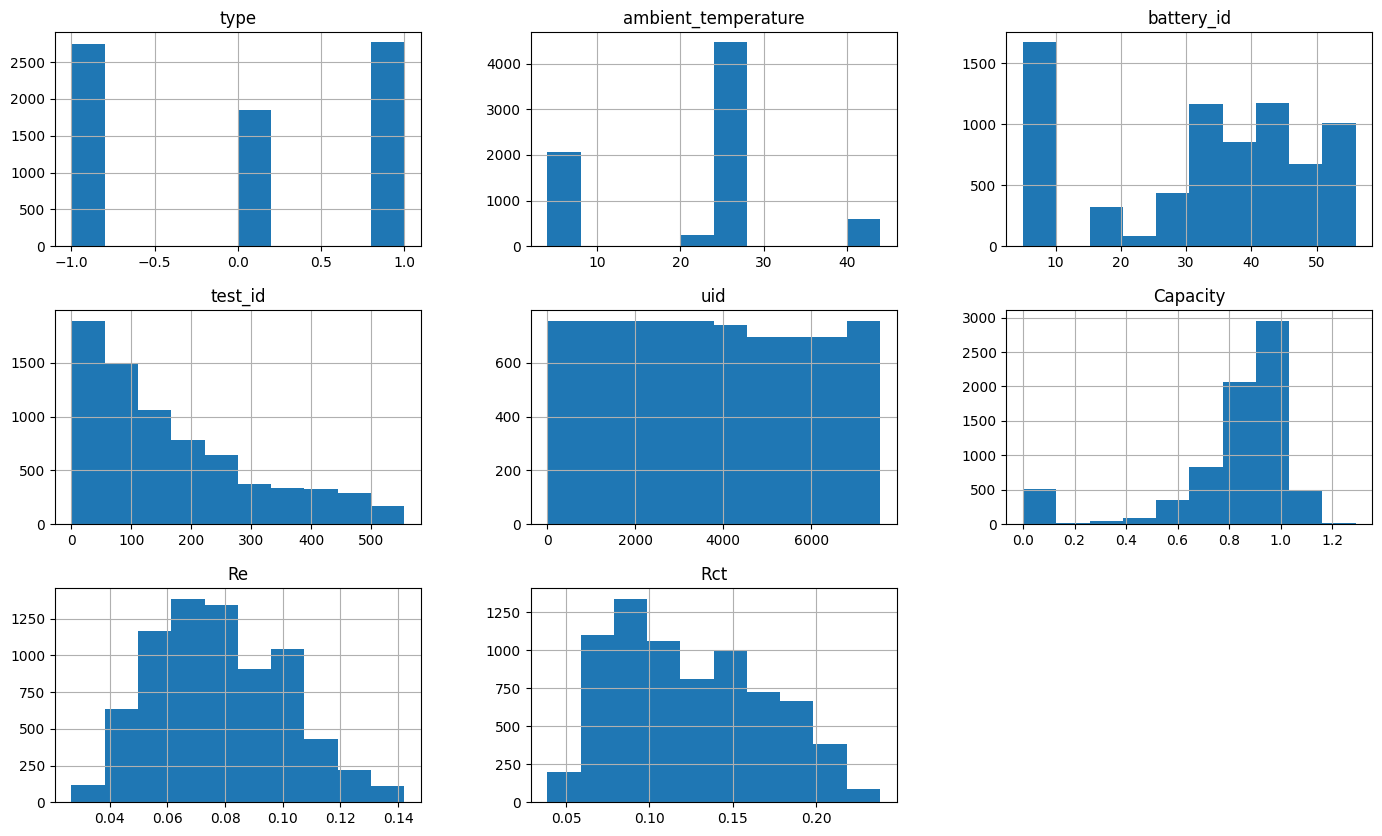

In [53]:
## Histogram

df_numeric.hist(figsize=(17,10))
plt.show()


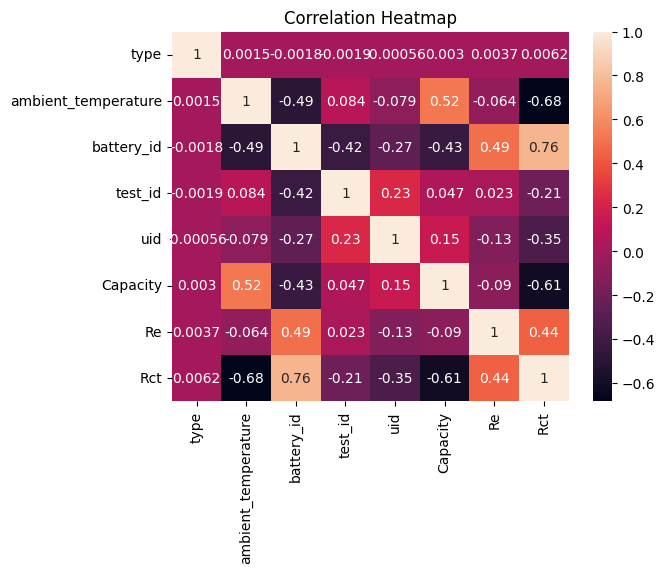

In [54]:
## Heat map

df_numeric = df.select_dtypes(include=[np.number])

sns.heatmap(df_numeric.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

The heatmap shows that Rct has a strong negative correlation with battery capacity, indicating degradation.

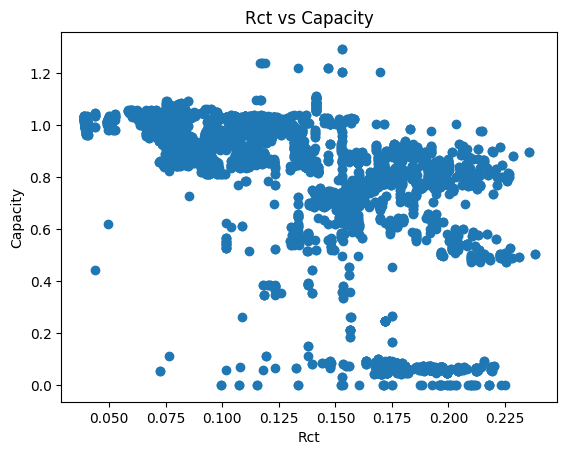

In [55]:
## Scatter

plt.scatter(df["Rct"], df["Capacity"])
plt.xlabel("Rct")
plt.ylabel("Capacity")
plt.title("Rct vs Capacity")
plt.show()

## FEATURE SELECTION

In [56]:
X = df[["ambient_temperature", "Re", "Rct"]]
y = df["Capacity"]

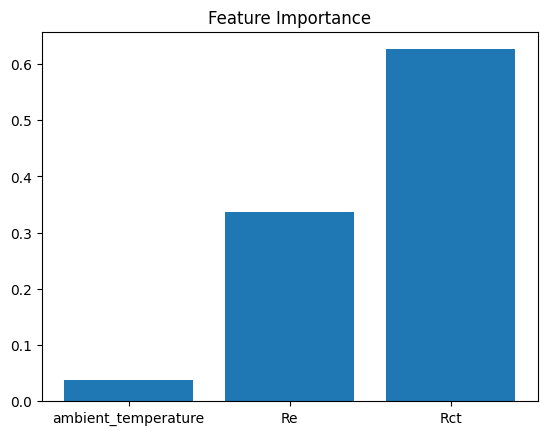

In [65]:
import pandas as pd

importance = rf.feature_importances_
features = X.columns

plt.bar(features, importance)
plt.title("Feature Importance")
plt.show()

Relevant features are selected while removing unnecessary identifiers

## TRAIN - TEST SPLIT

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## MODEL- 1 ( LINEAR REGRESSION )

In [58]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

## MODEL- 2 ( RANDOM FOREST )

In [59]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

## MODEL - 3 ( DECISION TREE )

In [60]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

### MODEL EVALUATION

In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Linear Regression")
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("MSE:", mean_squared_error(y_test, lr_pred))
print("R2:", r2_score(y_test, lr_pred))





Linear Regression
MAE: 0.1265480713258329
MSE: 0.03937746374348752
R2: 0.40694300543799844


In [62]:
## Random Forest

print("\nRandom Forest")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("MSE:", mean_squared_error(y_test, rf_pred))
print("R2:", r2_score(y_test, rf_pred))


Random Forest
MAE: 0.03467406835487848
MSE: 0.012076445492227375
R2: 0.8181187972067729


In [63]:
## Decision Tree

print("\nDecision Tree")
print("MAE:", mean_absolute_error(y_test, dt_pred))
print("MSE:", mean_squared_error(y_test, dt_pred))
print("R2:", r2_score(y_test, dt_pred))


Decision Tree
MAE: 0.03050716811614096
MSE: 0.013292941623814345
R2: 0.7997973648160293


### MODEL COMPARISON GRAPH

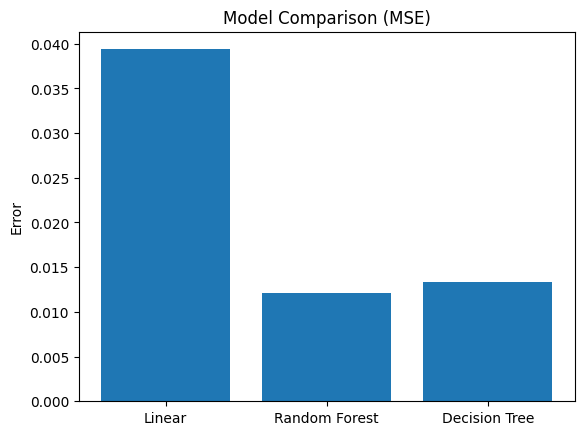

In [64]:
models = ["Linear", "Random Forest", "Decision Tree"]
mse_values = [
    mean_squared_error(y_test, lr_pred),
    mean_squared_error(y_test, rf_pred),
    mean_squared_error(y_test, dt_pred)
]

plt.bar(models, mse_values)
plt.title("Model Comparison (MSE)")
plt.ylabel("Error")
plt.show()

## Model Comparison

Among the three models, Random Forest achieved better performance compared to Linear Regression and Decision Tree. This is because Random Forest can handle complex relationships and reduce overfitting.

Therefore, Random Forest is selected as the best model for predicting battery health.